## Model Selection

Model selection is important part of any machine learning problem, So we run here multiple models and see which model performs very well on our data

In [2]:
import joblib
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier


In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from config import Config


In [4]:
engine = create_engine(Config.SQLALCHEMY_DATABASE_URI)
MODEL_PATH = Path("src/models/churn_model.pkl")

FEATURES = ["frequency", "monetary", "avg_order_value", "estimated_clv", "recency_ratio"]

In [5]:
df = pd.read_sql("SELECT * FROM rfm_features", engine)
df

,customer_id,recency_days,frequency,monetary,avg_days_between_orders,avg_order_value,estimated_clv,recency_ratio,is_churned
0,12346,326,12,77556.46,35.9091,6463.04,116334.72,9.0785,1
1,12347,2,8,4921.53,57.0000,615.19,7382.28,0.0351,0
2,12348,75,5,2019.40,90.5000,403.88,3029.10,0.8287,0
3,12349,19,4,4428.69,189.6667,1107.17,6643.02,0.1002,0
4,12350,310,1,334.40,310.0000,334.40,501.60,1.0000,1
...,...,...,...,...,...,...,...,...,...
5873,18283,4,22,2664.90,30.6667,121.13,3997.29,0.1304,0
5874,18284,432,1,461.68,432.0000,461.68,692.52,1.0000,1
5875,18285,661,1,427.00,661.0000,427.00,640.50,1.0000,1
5876,18286,477,2,1296.43,247.0000,648.22,1944.66,1.9312,1


In [6]:
X, y = df[FEATURES], df["is_churned"]
X

,frequency,monetary,avg_order_value,estimated_clv,recency_ratio
0,12,77556.46,6463.04,116334.72,9.0785
1,8,4921.53,615.19,7382.28,0.0351
2,5,2019.40,403.88,3029.10,0.8287
3,4,4428.69,1107.17,6643.02,0.1002
4,1,334.40,334.40,501.60,1.0000
...,...,...,...,...,...
5873,22,2664.90,121.13,3997.29,0.1304
5874,1,461.68,461.68,692.52,1.0000
5875,1,427.00,427.00,640.50,1.0000
5876,2,1296.43,648.22,1944.66,1.9312


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     eval_metric="logloss", random_state=42)
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc")

rfc = RandomForestClassifier(n_estimators=200, criterion="log_loss", max_depth=5, random_state=42
)
rfc_scores = cross_val_score(rfc, X_train, y_train, cv=cv, scoring="roc_auc")

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
logreg_scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="roc_auc")

# print("xgb_scores", xgb_scores)
print(f"XGBoost:  {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"Randomforest:  {rfc_scores.mean():.3f} ± {rfc_scores.std():.3f}")
print(f"LogReg:   {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}")

XGBoost:  0.925 ± 0.004
Randomforest:  0.924 ± 0.004
LogReg:   0.860 ± 0.011


### As we seen here XGBoost is performing well on our data, so we will go with the it and see on next metrics how will perform


In [9]:
model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=42,
    )

In [10]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
preds = model.predict(X_test)
preds
# probs = model.predict_proba(X_test)[:, 1]

array([0, 1, 0, ..., 0, 0, 0], shape=(1176,))

In [12]:
probs = model.predict_proba(X_test)[:, 1]
probs

array([1.0477768e-02, 7.7302587e-01, 4.5749134e-01, ..., 4.0288563e-04,
       1.4537766e-02, 1.5771938e-03], shape=(1176,), dtype=float32)

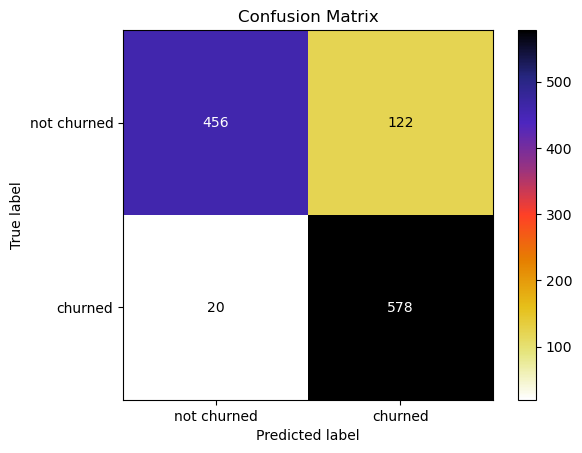

In [13]:
# visualizing the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=['not churned', 'churned']).plot(cmap='CMRmap_r')
plt.title('Confusion Matrix')
plt.show()

In [14]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.96      0.79      0.87       578
           1       0.83      0.97      0.89       598

    accuracy                           0.88      1176
   macro avg       0.89      0.88      0.88      1176
weighted avg       0.89      0.88      0.88      1176



### Now we will see how my model is performing well on different threshold

In [15]:
from sklearn.metrics import roc_curve

print(f"ROC-AUC: {roc_auc_score(y_test, probs):.3f}")
fpr, tpr, thresholds = roc_curve(y_test, probs)


ROC-AUC: 0.928


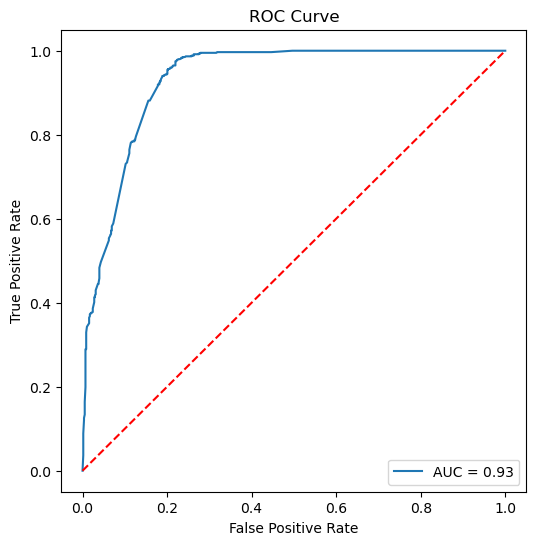

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, probs)

# AUC
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

# Random guessing line
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
xgb_scores = -cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

rfc_scores = -cross_val_score(
    rfc,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

logreg_scores = -cross_val_score(
    logreg,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)


In [23]:
print(
    f"XGBoost: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}\n"
    f"RandomForestClassifier: {rfc_scores.mean():.3f} ± {rfc_scores.std():.3f}\n"
    f"LogisticRegression: {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}"
)

XGBoost: -0.303 ± 0.017
RandomForestClassifier: -0.319 ± 0.014
LogisticRegression: -0.503 ± 0.007


In [18]:
xgb_logloss = -xgb_scores

print(
    f"XGBoost: {xgb_logloss.mean():.3f} ± {xgb_logloss.std():.3f}"
)

XGBoost: 0.303 ± 0.017


## **PR-AUC**

In [24]:
xgb_pr_scores = cross_val_score(
    xgb, X, y, cv=cv, scoring="average_precision"
)
rfc_pr_scores = cross_val_score(
    rfc, X, y, cv=cv, scoring="average_precision"
)

logreg_pr_scores = cross_val_score(
    logreg, X, y, cv=cv, scoring="average_precision"
)

In [25]:
print(
    f"XGBoost PR-AUC: {xgb_pr_scores.mean():.3f} ± {xgb_pr_scores.std():.3f}"
)

print(
    f"Random Forest PR-AUC: {rfc_pr_scores.mean():.3f} ± {rfc_pr_scores.std():.3f}"
)

print(
    f"Logistic Regression PR-AUC: {logreg_pr_scores.mean():.3f} ± {logreg_pr_scores.std():.3f}"
)

XGBoost PR-AUC: 0.904 ± 0.009
Random Forest PR-AUC: 0.901 ± 0.012
Logistic Regression PR-AUC: 0.865 ± 0.013


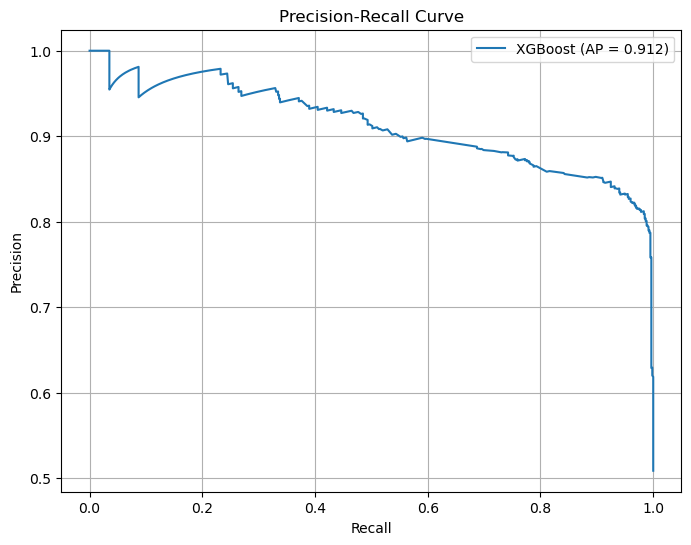

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

xgb.fit(X_train, y_train)

# Probability of churn (class = 1)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Precision and Recall at different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# PR-AUC
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"XGBoost (AP = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()